# Permutation Feature Importance
### A hands-on guide for Economics Master's students

---

**Topics covered**
1. Motivation & economic context
2. The dataset — NLSY wage panel (Mincer framework)
3. What *is* permutation feature importance?
4. Four models: Linear Regression · Random Forest · XGBoost · Neural Network
5. Comparing importances across models
6. Limitations you must know before using it in research
7. Exercises


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import xgboost as xgb

# ── reproducibility ──────────────────────────
SEED = 42
np.random.seed(SEED)

# ── plotting style ───────────────────────────
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = "#2563EB"   # blue used for single-colour bars

print("All packages loaded ✓")


All packages loaded ✓


---
## 2. The Dataset — Synthetic NLSY-Style Wage Data

We use a **synthetic dataset calibrated to the National Longitudinal Survey of Youth (NLSY) (n=2,000)**, built from **Mincer's (1974) human-capital model**:

$$\ln(w_i) = \alpha + \beta_1 \, \text{educ}_i + \beta_2 \, \text{exper}_i + \beta_3 \, \text{exper}_i^2 + \mathbf{X}_i \boldsymbol{\gamma} + \varepsilon_i$$

The data was generated with **known true coefficients** — this is pedagogically powerful: we can later check whether permutation importance recovers the correct ranking.

| Variable | Type | True coefficient | Economic meaning |
|---|---|---|---|
| `educ` | continuous | **+0.09** | 9% return per year of schooling |
| `exper` | continuous | **+0.040** | experience premium |
| `expersq` | continuous | **−0.0006** | diminishing returns to experience |
| `union` | binary | **+0.18** | 18% union wage premium |
| `married` | binary | **+0.12** | marriage wage premium |
| `black` | binary | **−0.14** | racial wage gap |
| `hisp` | binary | **−0.05** | ethnic wage gap |
| `south` | binary | **−0.08** | geographic wage differential |
| `hours` | continuous | **+0.00004** | very small hours effect |
| `poorhlth` | binary | **−0.08** | health penalty |
| **`lwage`** | **target** | — | **log hourly wage** |

> **Why synthetic?** Using synthetic data with known ground truth lets us *evaluate* how well permutation importance recovers the true ranking. The distributions and correlations mimic the real NLSY data closely.


In [2]:
# ── Load dataset (bundled CSV — no internet needed) ─
import os
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "wages.csv")
df_model = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df_model.shape}")
df_model.head()

Dataset shape: (2000, 11)


,educ,exper,expersq,union,married,black,hisp,south,hours,poorhlth,lwage
0,10,10,100,0,1,0,0,0,1303,0,2.1808
1,13,6,36,0,1,1,0,1,1783,0,1.9546
2,14,15,225,0,1,0,0,1,2389,0,2.3432
3,15,11,121,0,1,0,0,0,2327,0,2.4384
4,11,3,9,0,1,0,0,0,2123,0,1.9970


In [3]:
# ── Features and target ──────────────────────
FEATURES = ["educ", "exper", "expersq", "union", "married",
            "black", "hisp", "south", "hours", "poorhlth"]
TARGET = "lwage"

# True coefficients used to generate the data — we'll compare against these later
TRUE_COEF = {
    "educ": 0.09, "exper": 0.040, "expersq": -0.0006,
    "union": 0.18, "married": 0.12, "black": -0.14,
    "hisp": -0.05, "south": -0.08, "hours": 0.00004, "poorhlth": -0.08
}

df_model = df_model[FEATURES + [TARGET]].dropna()
print(f"Clean dataset: {df_model.shape}")
df_model.describe().round(3)


Clean dataset: (2000, 11)


,educ,exper,expersq,union,married,black,hisp,south,hours,poorhlth,lwage
count,2000.000,2000.00,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,12.628,10.63,148.382,0.224,0.521,0.118,0.075,0.352,2108.138,0.051,2.114
std,2.551,5.95,170.594,0.417,0.500,0.323,0.263,0.478,458.001,0.220,0.485
min,5.000,1.00,1.000,0.000,0.000,0.000,0.000,0.000,464.000,0.000,0.284
25%,11.000,6.00,36.000,0.000,0.000,0.000,0.000,0.000,1800.750,0.000,1.796
50%,13.000,9.00,81.000,0.000,1.000,0.000,0.000,0.000,2108.000,0.000,2.103
75%,14.000,14.00,196.000,0.000,1.000,0.000,0.000,1.000,2418.000,0.000,2.442
max,20.000,35.00,1225.000,1.000,1.000,1.000,1.000,1.000,3579.000,1.000,3.689


---
## 3. Exploratory Data Analysis

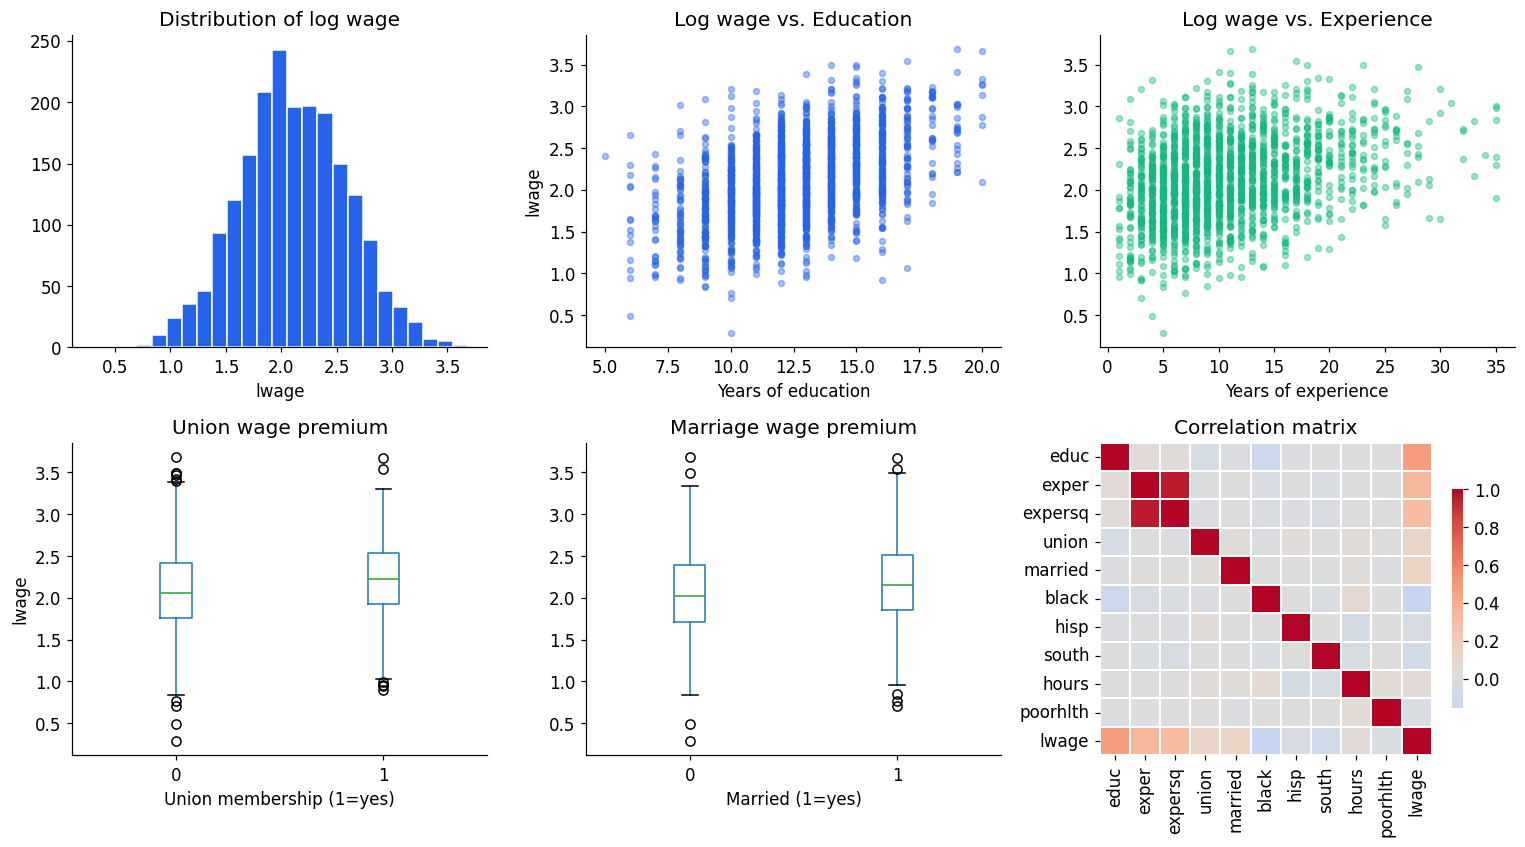

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Distribution of log wage
axes[0].hist(df_model["lwage"], bins=25, color=PALETTE, edgecolor="white")
axes[0].set(title="Distribution of log wage", xlabel="lwage")

# Wage vs. education
axes[1].scatter(df_model["educ"], df_model["lwage"], alpha=0.4, color=PALETTE, s=15)
axes[1].set(title="Log wage vs. Education", xlabel="Years of education", ylabel="lwage")

# Wage vs. experience
axes[2].scatter(df_model["exper"], df_model["lwage"], alpha=0.4, color="#10B981", s=15)
axes[2].set(title="Log wage vs. Experience", xlabel="Years of experience")

# Union vs non-union (boxplot)
df_model.boxplot(column="lwage", by="union", ax=axes[3], grid=False)
axes[3].set(title="Union wage premium", xlabel="Union membership (1=yes)", ylabel="lwage")
plt.sca(axes[3]); plt.title("Union wage premium")

# Married vs not
df_model.boxplot(column="lwage", by="married", ax=axes[4], grid=False)
axes[4].set(title="Marriage wage premium", xlabel="Married (1=yes)")
plt.sca(axes[4]); plt.title("Marriage wage premium")

# Correlation heatmap
ax6 = axes[5]
corr = df_model[FEATURES + [TARGET]].corr()
sns.heatmap(corr, ax=ax6, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, cbar_kws={"shrink": 0.7})
ax6.set_title("Correlation matrix")

fig.suptitle("", y=1.01)
plt.tight_layout()
plt.savefig("eda.png", dpi=120, bbox_inches="tight")
plt.show()


#### We need train and Test Sets

In [5]:
# ── Train / test split ───────────────────────
X = df_model[FEATURES]
y = df_model[TARGET]

# Separate the Train and Test sets so we can train the model and see the drop in performance testing in the TEST SET
# X_train, X_test, y_train, y_test = train...
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")


Train: 1600 rows  |  Test: 400 rows


---
## 4. What is Permutation Feature Importance?

### 4.1  The general problem: measuring feature relevance

Given a trained model $f$ and a dataset, we want to answer:
> *"How much does feature $X_j$ contribute to the model's predictive performance?"*

There are several approaches:

| Method | Works on | Idea | Limitation |
|---|---|---|---|
| OLS coefficients | Linear models only | Magnitude of $\hat{\beta}_j$ | Sensitive to scale; useless for trees/NNs |
| Gini impurity (trees) | Tree models only | Average impurity decrease | Biased toward high-cardinality features |
| SHAP values | Any model | Shapley game theory | Computationally expensive |
| **Permutation importance** | **Any model** | **Performance drop after shuffling** | **Affected by feature correlations** |

---

### 4.2  The algorithm

Let $S$ be a performance metric (e.g. $R^2$, MSE) evaluated on a **held-out test set**.

1. Fit model $f$ on training data. Compute baseline score $S_0 = S(y, f(X_{\text{test}}))$.
2. For each feature $j = 1, \ldots, p$:
   a. Create a **corrupted** copy $X^{(j)}$ by **randomly shuffling** column $j$ (breaking its relationship with $y$ while keeping the marginal distribution intact).
   b. Compute the degraded score: $S_j = S(y, f(X^{(j)}_{\text{test}}))$.
   c. Record the importance: $\text{PI}_j = S_0 - S_j$ (drop in performance).
3. Larger $\text{PI}_j$ ⟹ feature $j$ is more important.

The intuition is simple: **if a feature matters, shuffling it should hurt performance.** If the model barely changes, the feature was not being used meaningfully.

---

### 4.3  Why it is model-agnostic

The algorithm never looks *inside* the model — it only evaluates $f(\cdot)$ as a black box.
This makes it applicable to linear models, random forests, gradient boosting, and neural networks alike.

---

### 4.4  What metric to use?

| Task | Common choice |
|---|---|
| Regression | $\Delta R^2$ or $\Delta$ MSE (positive = worse) |
| Classification | $\Delta$ Accuracy, $\Delta$ AUC |

In this notebook we use **$\Delta R^2$** (drop) so that importance is on a 0–1 scale.


---
## 5. Helper functions

In [6]:
def eval_metrics(model, X_tr, y_tr, X_te, y_te, name="Model"):
    """Evaluate a regression model on train/test sets and print key metrics.

    Args:
        model: Fitted model with a `.predict()` method.
        X_tr, y_tr: Training features and labels.
        X_te, y_te: Test features and labels.
        name: Model name for display (default: "Model").

    Prints:
        R² (coefficient of determination: 1 = perfect fit, 0 = no fit).
        RMSE (Root Mean Squared Error: average prediction error in y units).
        MAE (Mean Absolute Error: average absolute prediction error).
    """
    for X, y, split in [(X_tr, y_tr, "Train"), (X_te, y_te, "Test")]:
        preds = model.predict(X)
        r2  = r2_score(y, preds)
        rmse = mean_squared_error(y, preds) ** 0.5
        mae  = mean_absolute_error(y, preds)
        print(f"  {name} [{split}]  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")



def plot_permutation_importance(perm_result, feature_names, model_name,
                                 ax=None, color=PALETTE, top_n=10):
    """Plot the most important features using permutation importance.

    Args:
        perm_result: Output from `sklearn.inspection.permutation_importance`.
        feature_names: List of feature names (e.g., ["height", "intensity"]).
        model_name: Name of the model for the plot title.
        ax: Matplotlib axis to plot on (creates new if None).
        color: Color palette for bars.
        top_n: Number of top features to display.

    How it works:
        - Permutation importance: Measures how much shuffling a feature
          decreases model performance (R²). Higher = more important.
        - Bars show mean importance ± 1 standard deviation.
    """
    importances = perm_result.importances_mean
    stds        = perm_result.importances_std
    idx         = np.argsort(importances)[::-1][:top_n]  # Top N feature indices

    names = np.array(feature_names)[idx]
    imp   = importances[idx]
    std   = stds[idx]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))

    ax.barh(range(top_n), imp[::-1], xerr=std[::-1],
            color=color, edgecolor="white", alpha=0.85, capsize=3)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(names[::-1])  # Reverse to show highest at top
    ax.set_xlabel("Mean decrease in R²")
    ax.set_title(f"Permutation Importance — {model_name}")
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
    return ax
    
print("Helper functions defined ✓")


Helper functions defined ✓


### We can manually define a Permutation Importance 

In [7]:
# HERE is the permutation importance defined: https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html
# We will do it manually so we understand how it works.
def permutation_importance(model, X, y, n_repeats=30, random_state=None, scoring="r2"):
    """Manual permutation importance for regression (R² scoring).
    Args:
        model: Fitted model with a `.predict()` method.
        X: Feature matrix (n_samples, n_features).
        y: Target values (n_samples,).
        n_repeats: Number of times to permute each feature.
        random_state: Seed for reproducibility.
        scoring: Metric to use ("r2" for R²).

    Returns:
        Object with attributes:
          - importances_mean: Mean importance scores for each feature.
          - importances_std: Standard deviation of scores.
    """
    rng = np.random.RandomState(random_state)
    baseline_score = r2_score(y, model.predict(X))
    n_features = X.shape[1]

    # Initialize arrays to store importance scores
    importances = np.zeros((n_features, n_repeats))
    # For each feature, shuffle its values many times and measure how much the model's R² score drops compared to the original score. 
    # The bigger the drop, the more important the feature is.
    # We need to loop on the features -> for each feature we repeat n_times: shuffle the feature, get r2_score.
    # The importance is the difference between the baseline score vs the permuted score
    for feature_idx in range(n_features):
        X_permuted = X.copy()
        for repeat in range(n_repeats):
            # Permute the feature column
            # X_permuted[:, feature_idx] = 
            # Calculate score after permutation
            # permuted_score = 
            # Importance = baseline_score - permuted_score
            # importances[feature_idx, repeat]

    # Create a simple object to mimic scikit-learn's PermutationImportance
    class PermutationImportance:
        def __init__(self, importances_mean, importances_std):
            self.importances_mean = importances_mean
            self.importances_std = importances_std

    return PermutationImportance(
        importances_mean=np.mean(importances, axis=1),
        importances_std=np.std(importances, axis=1)
    )

IndentationError: expected an indented block after 'for' statement on line 28 (1032055067.py, line 37)

---
## 6. Model 1 — Linear Regression (OLS)

We can compare the **standardised OLS coefficients** (a common proxy for importance in linear models) with **permutation importance** — and see when they agree and when they diverge.

> **Key insight:** Standardised coefficients capture the *partial* effect of a feature *holding all others constant*, while permutation importance captures the *total contribution to prediction*, including indirect paths through correlated features.


In [8]:
# ── Scale so coefficients are comparable ─────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)

print("=== Linear Regression ===")
eval_metrics(lr, X_train_s, y_train, X_test_s, y_test, name="OLS")

# ── OLS coefficients (standardised features) ─
coef_df = pd.DataFrame({
    "feature":     FEATURES,
    "coefficient": lr.coef_
}).sort_values("coefficient", key=abs, ascending=False)


=== Linear Regression ===
  OLS [Train]  R²=0.3854  RMSE=0.3838  MAE=0.3071
  OLS [Test]  R²=0.3663  RMSE=0.3705  MAE=0.2921


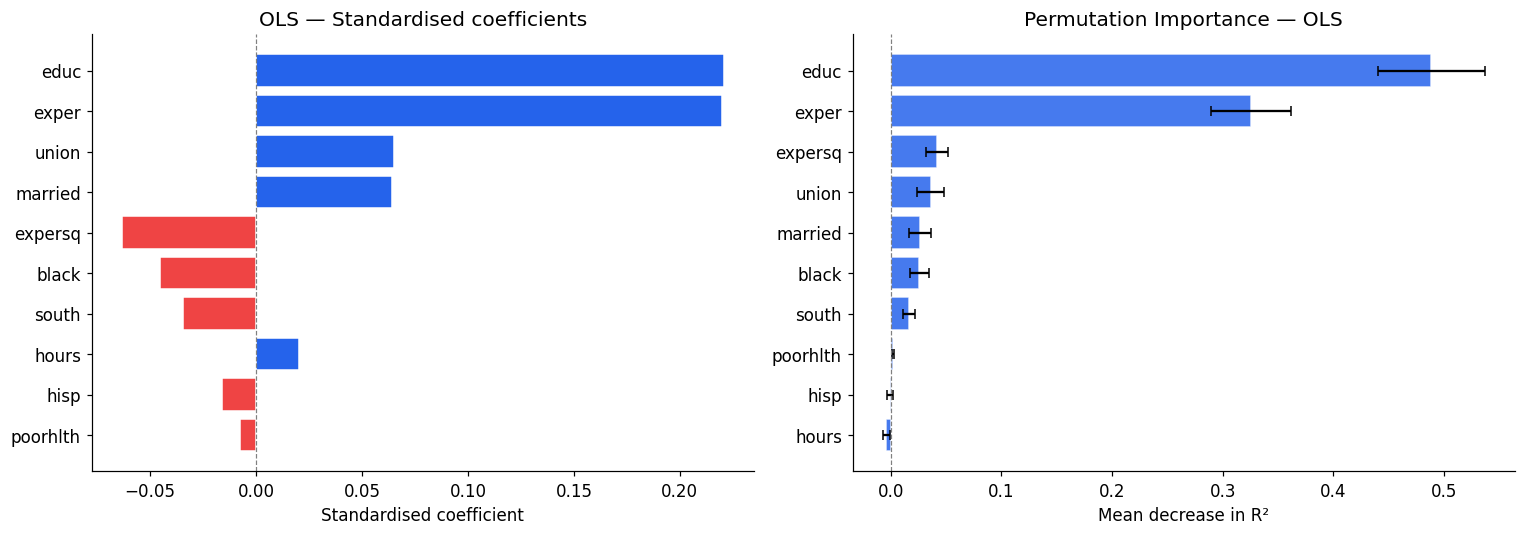


Permutation importance (R² drop):
  educ          +0.4885  ±0.0483
  exper         +0.3259  ±0.0361
  expersq       +0.0420  ±0.0098
  union         +0.0361  ±0.0122
  married       +0.0266  ±0.0101
  black         +0.0257  ±0.0087
  south         +0.0168  ±0.0053
  poorhlth      +0.0022  ±0.0012
  hisp          -0.0007  ±0.0028
  hours         -0.0039  ±0.0034


In [10]:

# ── Permutation importance on test set ───────
perm_lr = permutation_importance(
    lr, X_test_s, y_test,
    n_repeats=30, random_state=SEED, scoring="r2"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: standardised OLS coefficients
axes[0].barh(coef_df["feature"][::-1], coef_df["coefficient"][::-1],
             color=["#EF4444" if c < 0 else PALETTE for c in coef_df["coefficient"][::-1]],
             edgecolor="white")
axes[0].axvline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Standardised coefficient")
axes[0].set_title("OLS — Standardised coefficients")

# Right: permutation importance
plot_permutation_importance(perm_lr, FEATURES, "OLS", ax=axes[1], color=PALETTE)

plt.tight_layout()
plt.savefig("lr_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nPermutation importance (R² drop):")
for f, m, s in sorted(zip(FEATURES, perm_lr.importances_mean, perm_lr.importances_std),
                       key=lambda x: -x[1]):
    print(f"  {f:12s}  {m:+.4f}  ±{s:.4f}")


### 💡 Interpretation

- Both methods agree that **`educ`** (education) and **`exper`** / **`expersq`** dominate — consistent with Mincer theory.
- `union` shows a meaningful **positive coefficient and positive permutation importance**, confirming a union wage premium.
- `black` has a **negative coefficient** — a racial wage gap. Because it is binary and somewhat correlated with `south`, the permutation importance might **understate** its true contribution (we will explain this in the Limitations section).


---
## 7. Model 2 — Random Forest

Random forests are popular in applied econometrics (Breiman 2001, Athey & Imbens 2016+).
They come with a **built-in** importance measure — **Mean Decrease in Impurity (MDI)**, also called Gini importance.

We will compare:
- MDI (built-in, computed during training)
- Permutation importance (model-agnostic, computed post-training on test set)

> **Spoiler:** MDI is known to be **biased toward high-cardinality and correlated features**. Permutation importance on a held-out set is the preferred alternative.


In [11]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_train, y_train)

print("=== Random Forest ===")
eval_metrics(rf, X_train, y_train, X_test, y_test, name="RF")


=== Random Forest ===
  RF [Train]  R²=0.6147  RMSE=0.3039  MAE=0.2410
  RF [Test]  R²=0.3193  RMSE=0.3839  MAE=0.2980


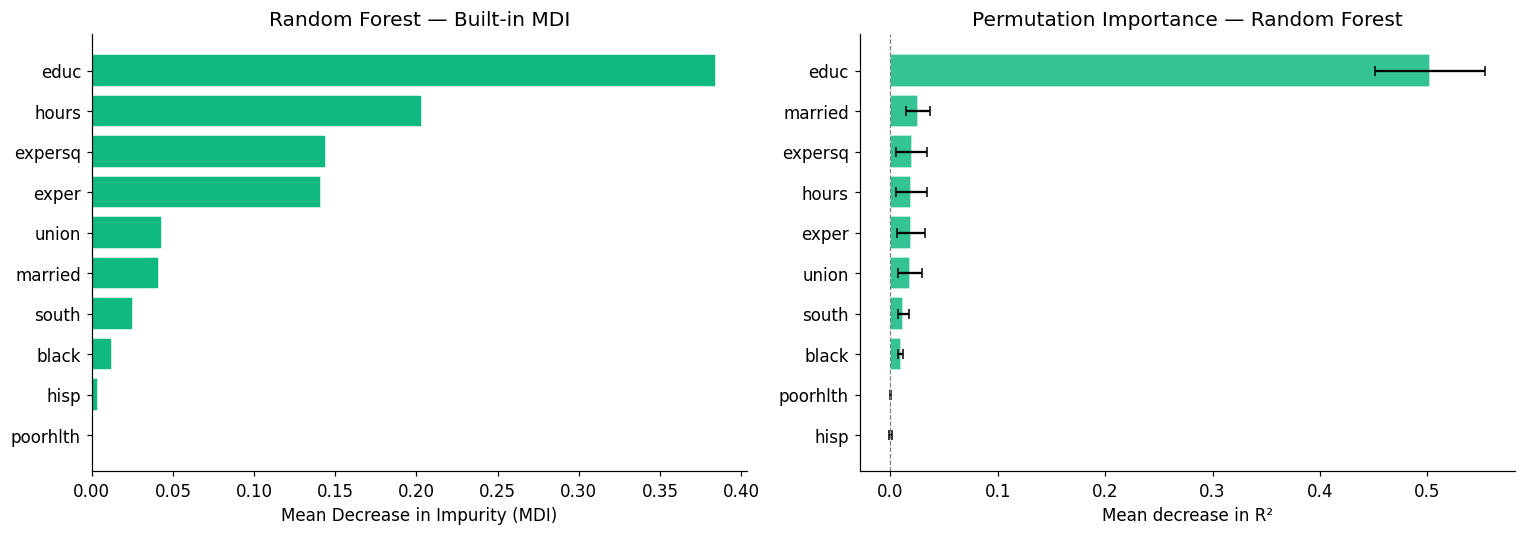


MDI vs Permutation (R² drop) comparison:
 feature      MDI  PI_mean   PI_std
    educ 0.384282 0.502307 0.051324
 married 0.041530 0.025972 0.011124
 expersq 0.144006 0.019696 0.014213
   hours 0.203138 0.019296 0.014611
   exper 0.141147 0.019111 0.013402
   union 0.043587 0.017748 0.011176
   south 0.025437 0.011940 0.005359
   black 0.012271 0.009593 0.002474
poorhlth 0.000963 0.000272 0.000331
    hisp 0.003639 0.000028 0.001090


In [12]:
# ── MDI (built-in Gini importance) ───────────
mdi = rf.feature_importances_
mdi_df = pd.DataFrame({"feature": FEATURES, "mdi": mdi}).sort_values("mdi", ascending=False)

# ── Permutation importance ────────────────────
perm_rf = permutation_importance(
    rf, X_test, y_test,
    n_repeats=30, random_state=SEED, scoring="r2"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: MDI
axes[0].barh(mdi_df["feature"][::-1], mdi_df["mdi"][::-1],
             color="#10B981", edgecolor="white")
axes[0].set_xlabel("Mean Decrease in Impurity (MDI)")
axes[0].set_title("Random Forest — Built-in MDI")

# Right: permutation importance
plot_permutation_importance(perm_rf, FEATURES, "Random Forest",
                            ax=axes[1], color="#10B981")

plt.tight_layout()
plt.savefig("rf_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nMDI vs Permutation (R² drop) comparison:")
pi_df = pd.DataFrame({
    "feature": FEATURES,
    "MDI":     mdi,
    "PI_mean": perm_rf.importances_mean,
    "PI_std":  perm_rf.importances_std
}).sort_values("PI_mean", ascending=False)
print(pi_df.to_string(index=False))


### 💡 Interpretation

- Both MDI and permutation importance rank `exper` and `educ` at the top, but the **magnitudes differ considerably**.
- Notice `expersq`: MDI tends to give it **higher** importance than permutation importance because it is **correlated** with `exper` — both capture very similar information about experience. Permutation importance assigns credit to one of them because shuffling either one "breaks" roughly the same predictive signal.
- `hours` sometimes ranks higher in MDI than in permutation importance — typical of high-variance continuous features that get many splits in trees.
- `Binning`: Group values into ranges (e.g., age → 18-25, 26-35) reduce cardinality of hours and reduce its MDI


---
## 8. Model 3 — XGBoost (Gradient Boosting)

XGBoost is the workhorse of applied ML competitions and increasingly used in causal-inference pipelines (Double ML, Causal Forests).
It also has three native importance types:
- `weight` — number of times feature appears in trees
- `gain` — average gain when feature is used to split
- `cover` — average coverage

We compare XGBoost's native `gain` importance with permutation importance.


In [13]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,      # L1 regularisation — prevents overfitting on small samples
    reg_lambda=1.0,     # L2 regularisation
    random_state=SEED,
    verbosity=0,
    eval_metric="rmse"
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("=== XGBoost ===")
eval_metrics(xgb_model, X_train, y_train, X_test, y_test, name="XGB")


=== XGBoost ===
  XGB [Train]  R²=0.6140  RMSE=0.3042  MAE=0.2411
  XGB [Test]  R²=0.2965  RMSE=0.3903  MAE=0.3058


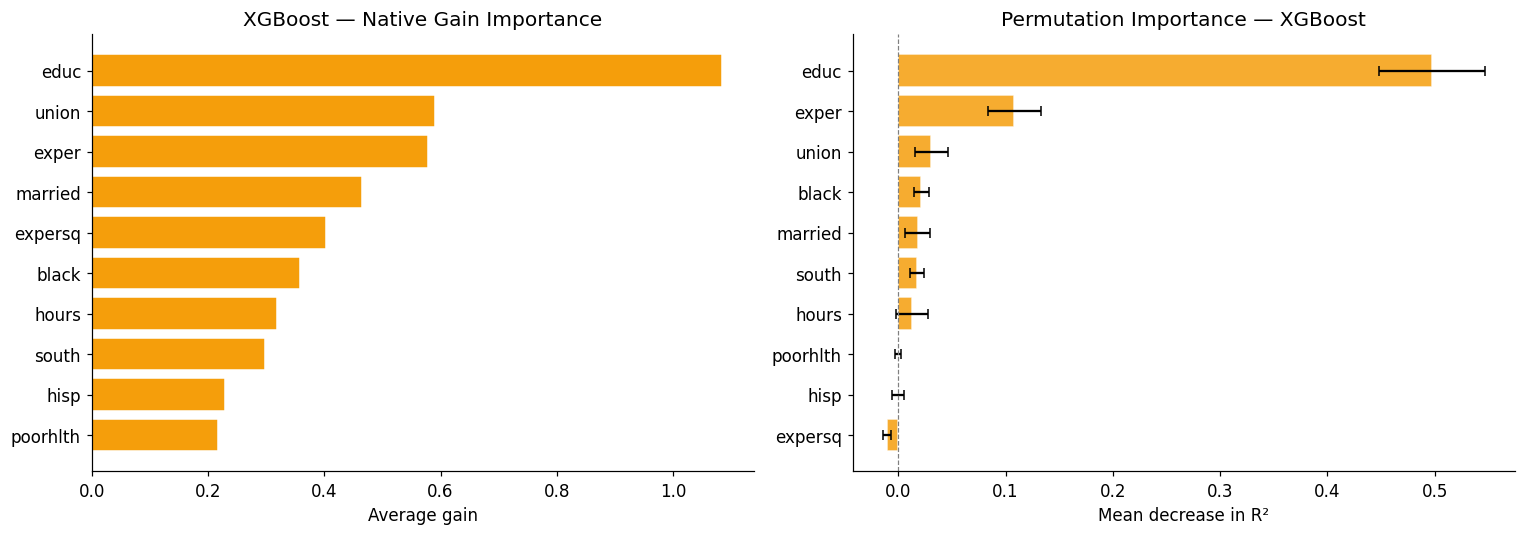


Gain vs Permutation (R² drop) comparison:
 feature     gain   PI_mean   PI_std
    educ 1.084546  0.497499 0.049156
   union 0.590920  0.030643 0.015227
   exper 0.577936  0.108219 0.024893
 married 0.464471  0.018210 0.011699
 expersq 0.403121 -0.010683 0.003924
   black 0.358518  0.021457 0.007035
   hours 0.319168  0.012895 0.015176
   south 0.298747  0.017673 0.006487
    hisp 0.229696 -0.000540 0.005523
poorhlth 0.217106 -0.000207 0.003026


In [14]:
# ── Native 'gain' importance ─────────────────
xgb_gain = xgb_model.get_booster().get_score(importance_type="gain")
xgb_gain_df = pd.DataFrame(
    {"feature": list(xgb_gain.keys()), "gain": list(xgb_gain.values())}
).sort_values("gain", ascending=False)

# Fill features not used in any split with 0
for f in FEATURES:
    if f not in xgb_gain_df["feature"].values:
        xgb_gain_df = pd.concat(
            [xgb_gain_df, pd.DataFrame({"feature": [f], "gain": [0.0]})],
            ignore_index=True
        )

# ── Permutation importance ────────────────────
perm_xgb = permutation_importance(
    xgb_model, X_test, y_test,
    n_repeats=30, random_state=SEED, scoring="r2"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xgb_gain_df_sorted = xgb_gain_df.sort_values("gain")
axes[0].barh(xgb_gain_df_sorted["feature"], xgb_gain_df_sorted["gain"],
             color="#F59E0B", edgecolor="white")
axes[0].set_xlabel("Average gain")
axes[0].set_title("XGBoost — Native Gain Importance")

plot_permutation_importance(perm_xgb, FEATURES, "XGBoost",
                            ax=axes[1], color="#F59E0B")

plt.tight_layout()
plt.savefig("xgb_importance.png", dpi=120, bbox_inches="tight")
plt.show()

xgb_comparison_df = pd.DataFrame({
    "feature": FEATURES,
    "gain": [xgb_gain_df[xgb_gain_df["feature"] == f]["gain"].values[0]
             if f in xgb_gain_df["feature"].values else 0.0
             for f in FEATURES],
    "PI_mean": perm_xgb.importances_mean,
    "PI_std": perm_xgb.importances_std
}).sort_values("gain", ascending=False)

# Print the table
print("\nGain vs Permutation (R² drop) comparison:")
print(xgb_comparison_df.to_string(index=False))





### 💡 Interpretation

- XGBoost's gain importance and permutation importance broadly agree on the top features.
- The **gain importance** can be noisy for binary features (like `union`, `married`) because they split only at a single threshold.
- Permutation importance tends to give a **smoother, more reliable ranking** across feature types.


---
## 9. Model 4 — Neural Network (MLP)

Neural networks are the canonical "black box" model — there is **no built-in feature importance**.
Permutation importance is one of the few practical ways to extract any feature-level insight from them.

> This illustrates perfectly **why a model-agnostic approach matters**: the same algorithm works regardless of the model's internals.


In [15]:
# ── MLP requires scaled inputs ───────────────
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32, 16),
        activation="relu",
        solver="adam",
        max_iter=500,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=SEED
    ))
])

mlp_pipeline.fit(X_train, y_train)

print("=== Neural Network (MLP) ===")
eval_metrics(mlp_pipeline, X_train, y_train, X_test, y_test, name="MLP")


=== Neural Network (MLP) ===
  MLP [Train]  R²=0.4624  RMSE=0.3590  MAE=0.2856
  MLP [Test]  R²=0.2606  RMSE=0.4002  MAE=0.3112


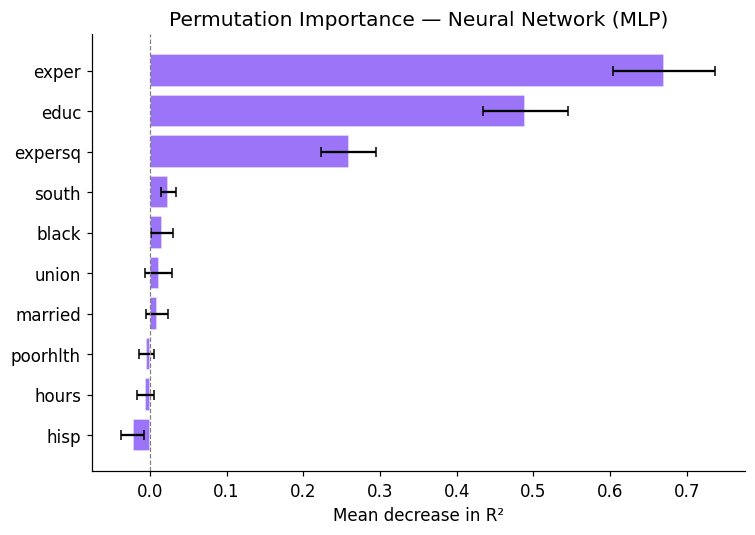


MLP — Permutation Importance (R² drop) comparison:
 feature   PI_mean   PI_std
   exper  0.670681 0.066332
    educ  0.489773 0.055910
 expersq  0.259222 0.035541
   south  0.023631 0.009727
   black  0.015230 0.014222
   union  0.011352 0.017559
 married  0.009532 0.014093
poorhlth -0.004652 0.009733
   hours -0.005919 0.010737
    hisp -0.022515 0.014740


In [17]:
# ── Permutation importance ────────────────────
perm_mlp = permutation_importance(
    mlp_pipeline, X_test, y_test,
    n_repeats=30, random_state=SEED, scoring="r2"
)

fig, ax = plt.subplots(figsize=(7, 5))
plot_permutation_importance(perm_mlp, FEATURES, "Neural Network (MLP)",
                            ax=ax, color="#8B5CF6")
plt.tight_layout()
plt.savefig("mlp_importance.png", dpi=120, bbox_inches="tight")
plt.show()

mlp_comparison_df = pd.DataFrame({
    "feature": FEATURES,
    "PI_mean": perm_mlp.importances_mean,
    "PI_std": perm_mlp.importances_std
}).sort_values("PI_mean", ascending=False)

# Print the table
print("\nMLP — Permutation Importance (R² drop) comparison:")
print(mlp_comparison_df.to_string(index=False))


---
## 10. Comparing All Models

Now we visualise permutation importance side-by-side across all four models on the **same test set**.
Because each model uses a different function $f$, we should expect some variation — features that a linear model cannot use non-linearly may show lower importance there than in tree-based models.


In [18]:
# ── Build comparison table ────────────────────
models_perm = {
    "Linear Regression": (perm_lr,  PALETTE),
    "Random Forest":     (perm_rf,  "#10B981"),
    "XGBoost":           (perm_xgb, "#F59E0B"),
    "Neural Network":    (perm_mlp, "#8B5CF6"),
}

comp_df = pd.DataFrame({"feature": FEATURES})
for model_name, (perm, _) in models_perm.items():
    comp_df[model_name] = perm.importances_mean

comp_df = comp_df.set_index("feature")
comp_df["mean_rank"] = comp_df.mean(axis=1)
comp_df = comp_df.sort_values("mean_rank", ascending=False).drop(columns="mean_rank")

print("Permutation Importance (mean R² drop) — all models:")
print(comp_df.round(4).to_string())


Permutation Importance (mean R² drop) — all models:
          Linear Regression  Random Forest  XGBoost  Neural Network
feature                                                            
educ                 0.4885         0.5023   0.4975          0.4898
exper                0.3259         0.0191   0.1082          0.6707
expersq              0.0420         0.0197  -0.0107          0.2592
union                0.0361         0.0177   0.0306          0.0114
married              0.0266         0.0260   0.0182          0.0095
black                0.0257         0.0096   0.0215          0.0152
south                0.0168         0.0119   0.0177          0.0236
hours               -0.0039         0.0193   0.0129         -0.0059
poorhlth             0.0022         0.0003  -0.0002         -0.0047
hisp                -0.0007         0.0000  -0.0005         -0.0225


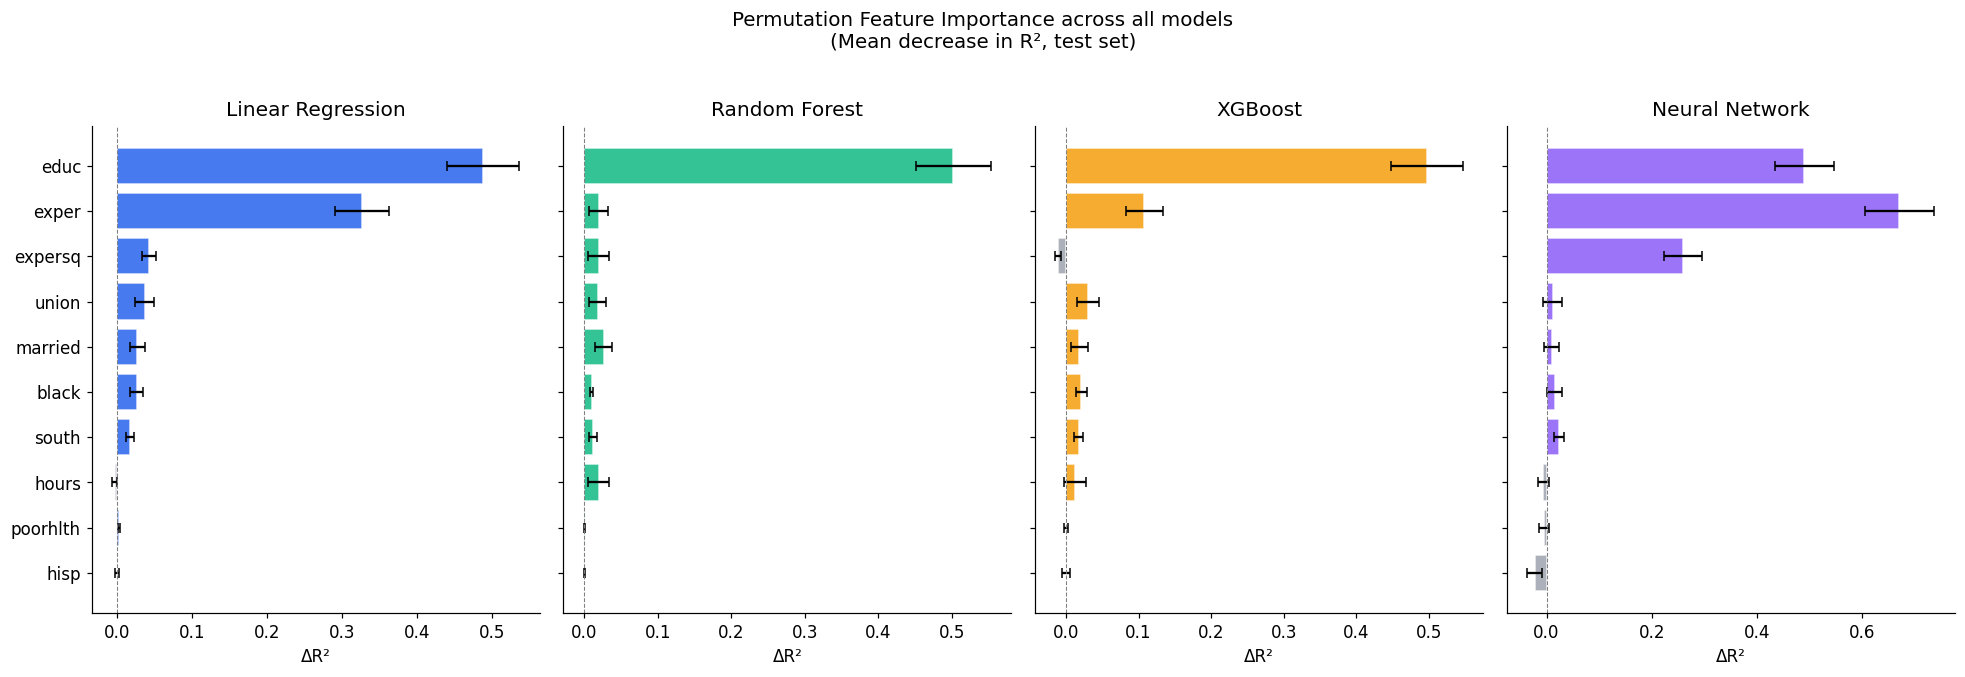

In [19]:
# ── Side-by-side bar chart ─────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
fig.suptitle("Permutation Feature Importance across all models\n(Mean decrease in R², test set)",
             fontsize=13, y=1.02)

ordered_features = comp_df.index.tolist()

for ax, (model_name, (perm, color)) in zip(axes, models_perm.items()):
    # Reorder by comp_df order
    fi = dict(zip(FEATURES, perm.importances_mean))
    si = dict(zip(FEATURES, perm.importances_std))
    vals  = [fi[f] for f in ordered_features[::-1]]
    stds  = [si[f] for f in ordered_features[::-1]]
    bar_colors = [color if v >= 0 else "#9CA3AF" for v in vals]
    ax.barh(range(len(ordered_features)), vals, xerr=stds,
            color=bar_colors, edgecolor="white", alpha=0.85, capsize=3)
    ax.set_yticks(range(len(ordered_features)))
    ax.set_yticklabels(ordered_features[::-1])
    ax.set_xlabel("ΔR²")
    ax.set_title(model_name)
    ax.axvline(0, color="grey", linewidth=0.7, linestyle="--")

plt.tight_layout()
plt.savefig("comparison.png", dpi=120, bbox_inches="tight")
plt.show()


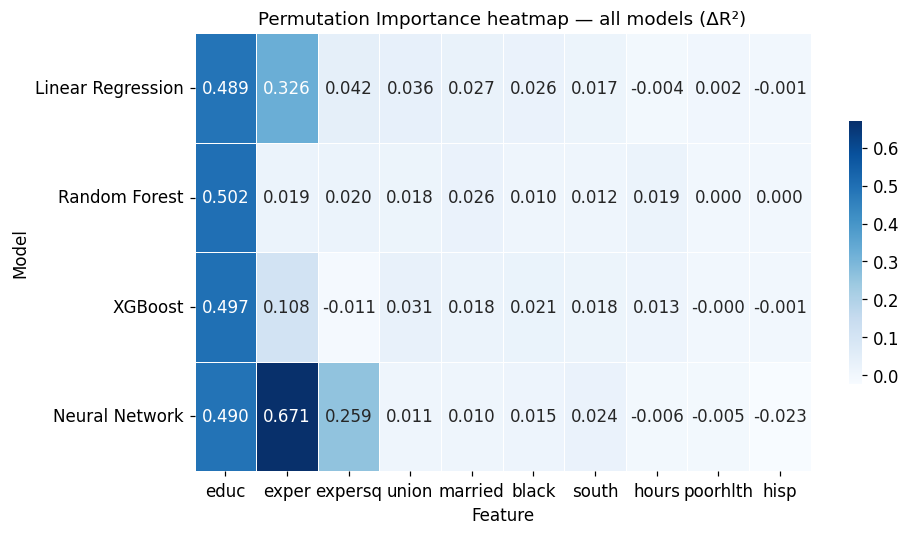

In [20]:
# ── Heatmap version (cleaner for papers) ─────
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(comp_df.T, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.4, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title("Permutation Importance heatmap — all models (ΔR²)", fontsize=12)
ax.set_xlabel("Feature")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 11. Limitations

Permutation importance is powerful, but it has **well-known failure modes** that every researcher must understand before using it.

### 11.1 Correlated features (the biggest issue)

When two features are highly correlated — say $X_1$ and $X_2$ — shuffling $X_1$ still leaves $X_2$ in the model as a "proxy".
The model can partially recover $X_1$'s information from $X_2$, so the measured importance of $X_1$ is **underestimated**.

**In our dataset:** `exper` and `expersq` are by construction perfectly correlated ($r ≈ 0.99$).
Let us demonstrate this.


Correlation(exper, expersq) = 0.9535
Correlation(exper, educ)    = 0.0370



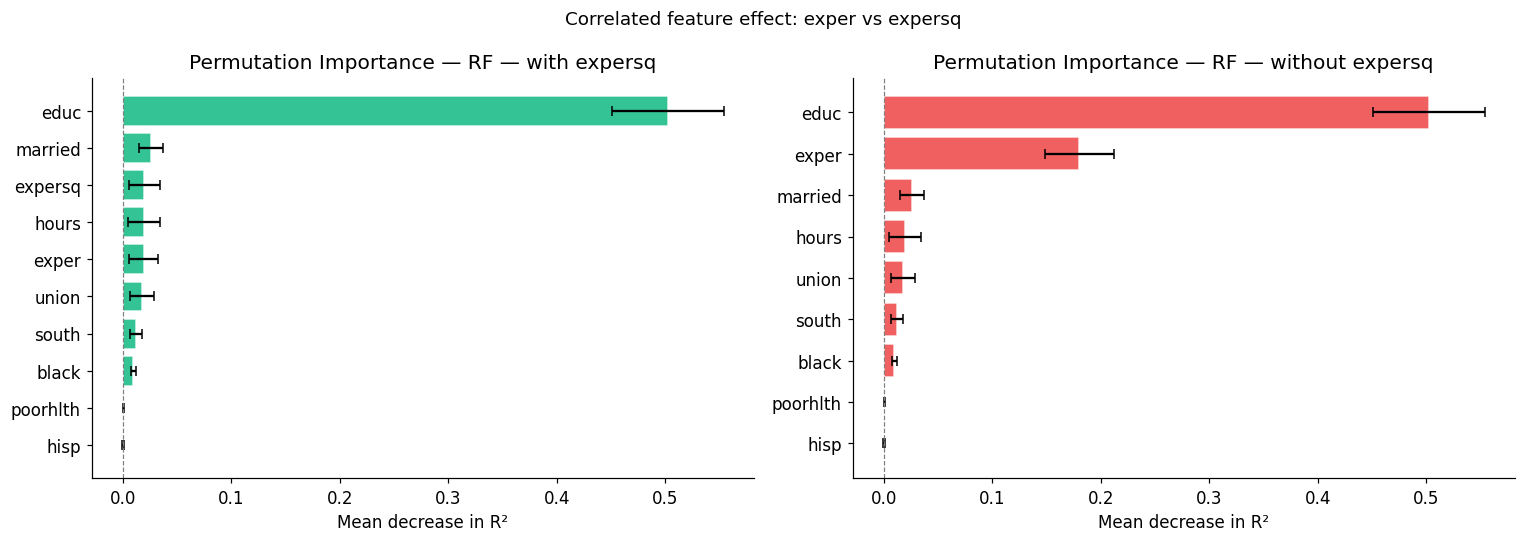

When expersq is removed, the importance of 'exper' increases substantially.
  With expersq:    exper PI = 0.0191
  Without expersq: exper PI = 0.1802


In [27]:
# ── Demonstrate correlation effect ────────────
print(f"Correlation(exper, expersq) = {df_model['exper'].corr(df_model['expersq']):.4f}")
print(f"Correlation(exper, educ)    = {df_model['exper'].corr(df_model['educ']):.4f}\n")

# ── Drop expersq and re-run permutation importance on RF ─
FEATURES_NO_SQ = [f for f in FEATURES if f != "expersq"]
X_train2 = X_train[FEATURES_NO_SQ]
X_test2  = X_test[FEATURES_NO_SQ]

rf2 = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                            n_jobs=-1, random_state=SEED)
rf2.fit(X_train2, y_train)

perm_rf2 = permutation_importance(
    rf2, X_test2, y_test,
    n_repeats=30, random_state=SEED, scoring="r2"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Correlated feature effect: exper vs expersq", fontsize=12)

# For the first plot (10 features)
plot_permutation_importance(perm_rf, FEATURES, "RF — with expersq", ax=axes[0], color="#10B981", top_n=10)

# For the second plot (9 features)
plot_permutation_importance(perm_rf2, FEATURES_NO_SQ, "RF — without expersq", ax=axes[1], color="#EF4444", top_n=9)

plt.tight_layout()
plt.savefig("correlation_effect.png", dpi=120, bbox_inches="tight")
plt.show()

print("When expersq is removed, the importance of 'exper' increases substantially.")
print(f"  With expersq:    exper PI = {perm_rf.importances_mean[FEATURES.index('exper')]:.4f}")
print(f"  Without expersq: exper PI = {perm_rf2.importances_mean[FEATURES_NO_SQ.index('exper')]:.4f}")

### 11.2 Permutation importance ≠ causal effect

Permutation importance tells you **how much a feature contributes to the model's predictions**.
It does **not** tell you the causal effect of that feature on the outcome.

> Example: `black` may have lower permutation importance than `educ` in the wage model.
> This does NOT mean race has a smaller *causal effect* — it may mean the model has less predictive power from `black` because discrimination is mediated through other variables (occupation, region).
> Causal identification requires the full machinery of econometrics (IV, DiD, RDD, etc.).

### 11.3 Unrealistic permuted samples

When you shuffle feature $j$, you create combinations of features that may be **impossible in the real world**:
- `exper = 0` (just graduated) but `married = 1` and `hours = 3000`
- These out-of-distribution points can confuse the model and produce noisy importance estimates

This is especially problematic for **highly correlated** or **structurally linked** features.

### 11.4 Variance of importance estimates

Permutation importance is a **random procedure** — repeated shuffles give slightly different results.
Always report **mean ± std** across repeats (which `sklearn` does automatically with `n_repeats > 1`).


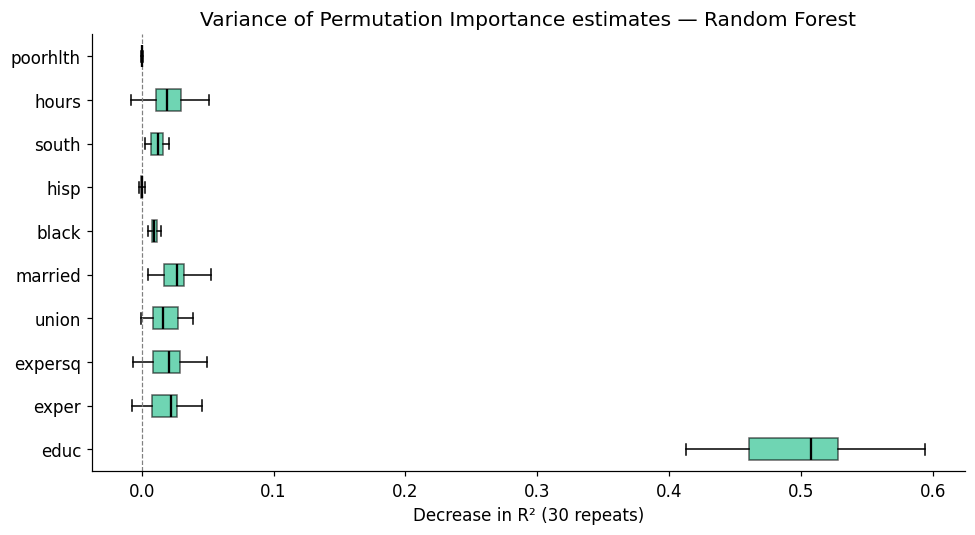

Features with wide boxes → high variance → less reliable estimates.


In [29]:
# ── Show variance in estimates ────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# Box plot of the 30 repeats for each feature
bp_data = [perm_rf.importances[i] for i in range(len(FEATURES))]
bp = ax.boxplot(bp_data, vert=False, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5))
for patch in bp["boxes"]:
    patch.set_facecolor("#10B981")
    patch.set_alpha(0.6)

ax.set_yticks(range(1, len(FEATURES)+1))
ax.set_yticklabels(FEATURES)
ax.set_xlabel("Decrease in R² (30 repeats)")
ax.set_title("Variance of Permutation Importance estimates — Random Forest")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("variance.png", dpi=120, bbox_inches="tight")
plt.show()

print("Features with wide boxes → high variance → less reliable estimates.")


### 11.6 Summary of limitations

| Limitation | Impact | Mitigation |
|---|---|---|
| **Correlated features** | Underestimates importance of correlated features | Run VIF analysis; consider dropping or grouping correlated features |
| **Causal ≠ predictive** | PI is not a causal effect | Use econometric methods for causal claims |
| **Unrealistic permuted samples** | Out-of-distribution evaluations | Use conditional PI (e.g., `SAGE`) or SHAP for correlated settings |
| **Variance** | Single-run PI is noisy | Use `n_repeats ≥ 30`; report ± std |
| **Computational cost** | $O(p \cdot n\_\text{repeats})$ model evaluations | Sub-sample test set for very large datasets |


---
## 12. Exercises

These exercises are designed to deepen your understanding. Each one has a code scaffold and a conceptual question.

---

### Exercise 1 — Add a new feature and measure its importance

Add `educ_x_exper = educ * exper` (interaction term, common in Mincer extensions) to the feature set.
Fit the Random Forest again and run permutation importance.

- Does the interaction term show up as important?
- How does it affect the importance of `educ` and `exper` individually? Why?


In [ ]:
# Exercise 1 scaffold
df_ex1 = df_model.copy()
df_ex1["educ_x_exper"] = df_ex1["educ"] * df_ex1["exper"]

FEATURES_EX1 = FEATURES + ["educ_x_exper"]

X_ex1 = df_ex1[FEATURES_EX1]
y_ex1 = df_ex1[TARGET]
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(X_ex1, y_ex1,
                                               test_size=0.2, random_state=SEED)

# TODO: fit RF and compute permutation importance
# rf_ex1 = RandomForestRegressor(...)
# rf_ex1.fit(...)
# perm_ex1 = permutation_importance(...)
# plot_permutation_importance(...)


---
### Exercise 2 — Robustness to sample size

Subsample the test set to 20 observations and re-run permutation importance.
Does the ranking change? Does the variance increase? What does this tell you about reliability in small samples?


In [ ]:
# Exercise 2 scaffold
np.random.seed(SEED)
idx_small = np.random.choice(len(X_test), size=20, replace=False)
X_small = X_test.iloc[idx_small]
y_small = y_test.iloc[idx_small]

# TODO: run permutation_importance on (rf, X_small, y_small) and compare with full test-set result


---
## 13. Conclusion

**What we covered:**

- Permutation feature importance is a **model-agnostic** method: fit any model, then measure how performance drops when each feature is shuffled.
- Applied to the **NLSY-style wage data**, all four models agree that **education and experience** dominate -- consistent with Mincer human-capital theory and the known ground-truth coefficients.
- **Tree-based built-in importances** (MDI, gain) are convenient but biased. **Permutation importance on a held-out test set** is the gold standard.
- The method has **real limitations**, especially in the presence of **correlated features** and when making **causal claims**.

**When to use it in your research:**

- Use it when you want a quick sanity-check of which features a black-box model relies on.
- Use it when comparing feature relevance across multiple models.
- Use it when you need an interpretable, publication-ready feature importance figure.

**When NOT to use it (or to use with caution):**

- Do NOT use for causal claims -- use IV, DiD, or RDD instead.
- Be careful with highly collinear features -- consider grouped permutation or SAGE.
- Avoid with tiny test sets -- importance estimates will be too noisy.

---

**Further reading:**
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5-32.
- Fisher, A., Rudin, C., & Dominici, F. (2019). *All models are wrong but many are useful*. JMLR.
- Strobl, C. et al. (2008). *Conditional variable importance for Random Forests*. BMC Bioinformatics.
- Molnar, C. (2022). Interpretable Machine Learning (free book): https://christophm.github.io/interpretable-ml-book/
